> **📎 EXAMPLE RUN — READ-ONLY ARTIFACT**
>
> This notebook is a **frozen record of a pipeline run** on the bundled example PDB (`example/HALP_example.pdb`, a homotrimeric antigen on chains A/B/C and antibody on chains D/G). It is preserved for reference only — cells are **not** meant to be re-executed here.
>
> The selected rescue mutations reported by this run are **S108L · T100L · T104V** (top-3 non-key-binding positions on chain D by ascending WT unbound logit; Step 5's final key-binding set combines Δ-flagged residues with the user-supplied `D52`, `D53`).
>
> **To run your own analysis**, use the fresh notebook at `../expression_rescue.ipynb` — it has the same code with outputs cleared.
>
> ---
>
> ⚠️ **Note on the Step 8 3-D views:** GitHub renders notebooks with JavaScript **disabled** for security. The `py3Dmol` cell output relies on the 3Dmol.js library loaded from an external CDN, so here on GitHub you will see an error banner (`3Dmol.js failed to load for some reason`) instead of the interactive structure. **This is a GitHub rendering limitation, not a pipeline problem.** When you open this notebook locally (Jupyter / JupyterLab / VS Code), the 3-D views render normally. The underlying `.pdb` files with B-factor-encoded logits are also saved to `example/example_output/` and the other static outputs (heatmap, CSVs) display correctly here.

# Expression Rescue Pipeline

Given an antibody-antigen bound complex PDB, this notebook proposes single-point mutations in CDR loops that may **rescue antibody expression** without disrupting antigen binding.

> **⚠ The final output is the list of selected rescue mutations printed at the end of Step 6** (e.g. `V52S, S108L, T100L`). Everything else — the heatmap, logit-colored PDBs, per-residue CSVs, and 3-D views — is **additional information** that helps you understand how those mutations were selected.

> **⚠ Output quality depends on input structure quality.** This pipeline reads per-residue structural context (backbone geometry + local environment) to produce the logits that drive every downstream decision. If the input complex has low resolution, misfolded regions, poor quality, etc., the resulting rescue mutations may be unreliable. Prefer high-resolution crystal/cryo-EM structures, or high-quality predicted structures with energy-minimization whose binding interface has been validated.

**Method.** We run ProteinMPNN single-AA scoring on two states:

- **bound**: the input complex as-is
- **unbound**: the same complex with the antigen chain(s) removed

ProteinMPNN produces per-residue logits over the 21-letter amino acid alphabet conditional on the structural context. Comparing the two states residue-by-residue yields two actionable signals:

| Signal | Definition | Interpretation |
|--------|------------|----------------|
| **Key binding residues** | Positions where the wild-type amino acid has a much higher logit in the bound state than in the unbound state (Δ = logit_bound - logit_unbound > threshold) | The residue is *preferred because of* the antigen contact - changing it would likely cost binding affinity. |
| **Rescue candidates** | Positions where an alternative amino acid has a higher logit in the unbound state than the current wild-type amino acid | The residue is already suboptimal for the antibody alone - a substitution may improve expression/stability without touching the binding interface. |

The notebook runs end-to-end for **one input complex per invocation**. Configure the user-input cell below and run all cells.

In [1]:
import csv
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
import seaborn as sns
import torch
from IPython.display import HTML, Markdown, display

from prody import parsePDB, writePDB

/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import torch; print(torch.cuda.is_available(), torch.cuda.device_count())

True 1


## Step 0 - Get user input

Get user inputs including initial Ab-Ag complex pdb, antigen & rescue residues information, output directory, various hyperparameters, etc. Edit this cell, then Run All.

In [3]:
# Input structure: antibody-antigen complex PDB file.
bound_pdb_path = "example/HALP_example.pdb"

# Chain letter(s) of the antigen. Everything else is treated as the antibody.
# The example PDB has a homotrimeric antigen on chains A, B, C and antibody on D (heavy) + G (light).
antigen_chain_ids = ["A", "B", "C"]

# Residues to evaluate for rescue (CDR positions, hotspots, ...).
# Format: "<chain_letter><resnum>" strings.
# Example: CDR-H2 and CDR-H3 of the heavy chain (chain D).
rescue_residues = [
    # CDR-H2
    "D50", "D51", "D52", "D53", "D54", "D55", "D56", "D57",
    "D58", "D59", "D60", "D61", "D62", "D63", "D64", "D65",
    # CDR-H3
    "D95", "D96", "D97", "D98", "D99", "D100", "D101", "D102",
    "D103", "D104", "D105", "D106", "D107", "D108", "D109", "D110",
]

# Output directory (will be created if missing).
output_dir = "output"

# ProteinMPNN scoring backend (bundled alongside this notebook).
protein_mpnn_dir = "ProteinMPNN"
weights_path = "ProteinMPNN/model_params/proteinmpnn_v_48_020.pt"

# Analysis thresholds / knobs.
binding_logit_threshold = 1.0   # delta > threshold -> key binding residue (Step 5)
top_k_rescue = 3                # highlight the K lowest-WT-preference positions in Step 6

# ----- Optional: user-supplied key-binding residues -----
# If you already know certain positions are binding-critical (from experimental
# mutagenesis, prior literature, epitope mapping, etc.), list them here.
# Leave empty to rely entirely on the pipeline's Δ-based detection.
user_key_binding_residues = ["D52", "D53"]

# How to combine user-supplied residues with Step 5's Δ-based detection.
# Only consulted when user_key_binding_residues is non-empty.
#   "union"     — final set = pipeline-detected ∪ user-supplied (most conservative)
#   "user_only" — final set = user-supplied only (pipeline Δ detection ignored)
user_key_binding_mode = "union"       # "union" | "user_only"

# Scoring hyperparameters (match the values used in the reference study).
batch_size = 10
number_of_batches = 1

# Resolve to absolute paths and create output subdirs.
bound_pdb_path = str(Path(bound_pdb_path).resolve())
output_dir = Path(output_dir).resolve()
bound_out_dir = output_dir / "bound"
unbound_out_dir = output_dir / "unbound"
for d in (output_dir, bound_out_dir, unbound_out_dir):
    d.mkdir(parents=True, exist_ok=True)

stem = Path(bound_pdb_path).stem
print(f"Input PDB  : {bound_pdb_path}")
print(f"Output dir : {output_dir}")
print(f"Rescue residues: {len(rescue_residues)}")
if user_key_binding_residues:
    print(f"User-specified key-binding residues: {user_key_binding_residues}  (mode='{user_key_binding_mode}')")
else:
    print("User-specified key-binding residues: (none — pipeline detection only)")

Input PDB  : /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/HALP_example.pdb
Output dir : /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output
Rescue residues: 32
User-specified key-binding residues: ['D52', 'D53']  (mode='union')


## Step 1 - Generate the unbound PDB

Strip the antigen chain(s) from the bound complex and write a companion PDB. This file is the "unbound" input for ProteinMPNN - same antibody coordinates, no antigen context.

In [4]:
unbound_pdb_path = output_dir / f"{stem}_unbound.pdb"

bound_structure = parsePDB(bound_pdb_path)
if bound_structure is None:
    raise RuntimeError(f"ProDy failed to parse {bound_pdb_path}")

antigen_selector = " or ".join(f"chain {c}" for c in antigen_chain_ids)
antibody_selection = bound_structure.select(f"not ({antigen_selector})")
if antibody_selection is None:
    raise RuntimeError(
        f"Removing chains {antigen_chain_ids} left no atoms - check antigen_chain_ids."
    )

writePDB(str(unbound_pdb_path), antibody_selection)

n_bound = bound_structure.numAtoms()
n_unbound = antibody_selection.numAtoms()
print(f"Bound atoms  : {n_bound}")
print(f"Unbound atoms: {n_unbound}  (removed {n_bound - n_unbound} antigen atoms)")
print(f"Wrote unbound PDB -> {unbound_pdb_path}")

Bound atoms  : 5423
Unbound atoms: 1754  (removed 3669 antigen atoms)
Wrote unbound PDB -> /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/HALP_example_unbound.pdb


## Step 2 - Run ProteinMPNN scoring

Invoke the bundled `ProteinMPNN/score.py` twice, once per state. The scoring mode is:

- `--single_aa_score 1` - p(AA_i | backbone, AA_{all except i})
- `--use_sequence 1` - condition on the native sequence (bound: full complex sequence; unbound: antibody-only sequence)

Each run produces a single `.pt` file inside `output/{bound,unbound}/`.

In [5]:
def run_scoring(pdb_path, out_folder):
    """Invoke ProteinMPNN/score.py on one PDB. Returns the path to the written .pt file."""
    cmd = [
        sys.executable, "-u", "score.py",
        "--pdb_path", str(pdb_path),
        "--out_folder", str(out_folder),
        "--model_type", "protein_mpnn",
        "--checkpoint_protein_mpnn", str(Path(weights_path).resolve()),
        "--batch_size", str(batch_size),
        "--number_of_batches", str(number_of_batches),
        "--single_aa_score", "1",
        "--use_sequence", "1",
    ]
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=str(Path(protein_mpnn_dir).resolve()), check=True)
    pt_path = Path(out_folder) / f"{Path(pdb_path).stem}.pt"
    if not pt_path.exists():
        raise RuntimeError(f"Expected scoring output not found: {pt_path}")
    return pt_path

bound_pt = run_scoring(bound_pdb_path, bound_out_dir)
unbound_pt = run_scoring(unbound_pdb_path, unbound_out_dir)
print(f"\nBound scores  : {bound_pt}")
print(f"Unbound scores: {unbound_pt}")

$ /home/fullmoon/.conda/envs/expression_rescue/bin/python3.10 -u score.py --pdb_path /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/HALP_example.pdb --out_folder /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound --model_type protein_mpnn --checkpoint_protein_mpnn /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/ProteinMPNN/model_params/proteinmpnn_v_48_020.pt --batch_size 10 --number_of_batches 1 --single_aa_score 1 --use_sequence 1


/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Designing protein from this path: /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/HALP_example.pdb
These residues will be redesigned:  ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A1

/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Designing protein from this path: /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/HALP_example_unbound.pdb
These residues will be redesigned:  ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31', 'D32', 'D33', 'D34', 'D35', 'D36', 'D37', 'D38', 'D39', 'D40', 'D41', 'D42', 'D43', 'D44', 'D45', 'D46', 'D47', 'D48', 'D49', 'D50', 'D51', 'D52', 'D53', 'D54', 'D55', 'D56', 'D57', 'D58', 'D59', 'D60', 'D61', 'D62', 'D63', 'D64', 'D65', 'D66', 'D67', 'D68', 'D69', 'D70', 'D71', 'D72', 'D73', 'D74', 'D75', 'D76', 'D77', 'D78', 'D79', 'D80', 'D81', 'D82', 'D83', 'D84', 'D85', 'D86', 'D87', 'D88', 'D89', 'D90', 'D91', 'D92', 'D93', 'D94', 'D95', 'D96', 'D97', 'D98', 'D99', 'D100', 'D101', 'D102', 'D103', 'D104', 'D105', 'D106', 'D107', 'D108', 'D109', 'D110', 'D111', 'D112', 'D113', 'D114', 'D115', 'D116', 'D11

## Step 3 - Load scoring results

The `.pt` files hold an aggregate dict per scoring run. The keys we need are:

- `mean_of_logits`: dict mapping `"<chain><resnum>"` -> `{AA letter -> logit}`
- `sequence`: list of WT amino acid letters aligned to `residue_names`
- `residue_names`: dict mapping integer index -> `"<chain><resnum>"` string

In [6]:
bound_data = torch.load(bound_pt, map_location="cpu", weights_only=False)
unbound_data = torch.load(unbound_pt, map_location="cpu", weights_only=False)

bound_logits = bound_data["mean_of_logits"]
unbound_logits = unbound_data["mean_of_logits"]
alphabet = bound_data["alphabet"]

# Map residue_name -> WT AA letter (from the integer-indexed sequence + residue_names).
def wt_map(data):
    idx_to_name = data["residue_names"]
    seq = data["sequence"]
    return {idx_to_name[i]: seq[i] for i in range(len(seq))}

wt_bound = wt_map(bound_data)
wt_unbound = wt_map(unbound_data)

missing_bound = [r for r in rescue_residues if r not in bound_logits]
missing_unbound = [r for r in rescue_residues if r not in unbound_logits]
if missing_bound or missing_unbound:
    raise KeyError(
        "Rescue residues not found in scoring output:\n"
        f"  bound   missing: {missing_bound}\n"
        f"  unbound missing: {missing_unbound}\n"
        "Check chain letters and residue numbers in the input PDB."
    )

print(f"Alphabet ({len(alphabet)}): {''.join(alphabet)}")
print(f"Bound residues scored  : {len(bound_logits)}")
print(f"Unbound residues scored: {len(unbound_logits)}")

Alphabet (21): ACDEFGHIKLMNPQRSTVWYX
Bound residues scored  : 699
Unbound residues scored: 228


## Step 4 - Gather per-residue logit matrices

For each rescue residue, stack the bound and unbound logits across the 21-letter alphabet. Rows are sorted first by chain letter then by residue number (so `B30, B31, ..., C24, C25, ...` rather than lexicographic `B100` before `B30`).

In [7]:
def res_sort_key(name):
    """'B30' -> ('B', 30). Assumes single-letter chain; extend if multi-letter chains are used."""
    m = re.match(r"([A-Za-z]+)(\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse residue name: {name}")
    return (m.group(1), int(m.group(2)))

ordered_residues = sorted(rescue_residues, key=res_sort_key)
n_res = len(ordered_residues)
n_aa = len(alphabet)

bound_mat = np.zeros((n_res, n_aa), dtype=float)
unbound_mat = np.zeros((n_res, n_aa), dtype=float)
wt_aas = []

for i, res in enumerate(ordered_residues):
    b = bound_logits[res]
    u = unbound_logits[res]
    bound_mat[i] = [b.get(aa, 0.0) for aa in alphabet]
    unbound_mat[i] = [u.get(aa, 0.0) for aa in alphabet]
    wt = wt_bound[res]
    if wt_unbound[res] != wt:
        print(f"[warn] WT mismatch at {res}: bound={wt} unbound={wt_unbound[res]}")
    wt_aas.append(wt)

diff_mat = bound_mat - unbound_mat
print(f"Stacked logits for {n_res} residues x {n_aa} AAs.")

Stacked logits for 32 residues x 21 AAs.


## Step 5 - Identify key binding residues

For each rescue residue, compute Δ = logit_bound(WT) − logit_unbound(WT). Residues with Δ > `binding_logit_threshold` are flagged as binding-critical — the antigen contact is what makes the current WT amino acid the preferred choice.

**Optional user override.** If `user_key_binding_residues` is non-empty, the final key-binding set used downstream is:

- `"union"` — pipeline-detected ∪ user-supplied
- `"user_only"` — user-supplied only (pipeline Δ detection ignored)

Both the Δ-based flag (`is_key_binding`) and the user flag (`user_specified`) are kept in `key_binding_residues.csv` for transparency; the column that actually drives Step 6's top-K exclusion is `is_final_key_binding`.

In [8]:
aa_to_col = {aa: i for i, aa in enumerate(alphabet)}

# ── Δ-based detection ────────────────────────────────────────────────────
key_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    col = aa_to_col[wt]
    b = float(bound_mat[i, col])
    u = float(unbound_mat[i, col])
    key_rows.append({
        "position": res,
        "WT_aa": wt,
        "WT_bound_logit": b,
        "WT_unbound_logit": u,
        "delta": b - u,
        "is_key_binding": (b - u) > binding_logit_threshold,
    })

# ── Combine with user-supplied residues ──────────────────────────────────
pipeline_kb = {r["position"] for r in key_rows if r["is_key_binding"]}
user_kb_requested = set(user_key_binding_residues)
user_kb_unknown = user_kb_requested - set(ordered_residues)
user_kb = user_kb_requested & set(ordered_residues)

if not user_kb:
    final_key_binding_positions = pipeline_kb
    mode_note = "no user input — pipeline detection only"
elif user_key_binding_mode == "union":
    final_key_binding_positions = pipeline_kb | user_kb
    mode_note = f"union ({len(pipeline_kb)} pipeline ∪ {len(user_kb)} user)"
elif user_key_binding_mode == "user_only":
    final_key_binding_positions = user_kb
    mode_note = f"user_only ({len(user_kb)} user; Δ detection ignored)"
else:
    raise ValueError(
        f"Unknown user_key_binding_mode: {user_key_binding_mode!r} "
        "(use 'union' or 'user_only')."
    )

for row in key_rows:
    row["user_specified"] = row["position"] in user_kb
    row["is_final_key_binding"] = row["position"] in final_key_binding_positions

# ── DataFrame + save CSV ─────────────────────────────────────────────────
df_key = (
    pd.DataFrame(key_rows)
    .sort_values("delta", ascending=False)
    .reset_index(drop=True)
)
key_csv = output_dir / "key_binding_residues.csv"
df_key.to_csv(key_csv, index=False)

# ── Styled display ───────────────────────────────────────────────────────
max_abs_delta = max(abs(df_key["delta"].min()), abs(df_key["delta"].max()), 1e-6)
non_gradient_cols = [c for c in df_key.columns if c != "delta"]

def _highlight_final(row):
    if row["is_final_key_binding"]:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)

styled = (
    df_key.style
    .format({
        "WT_bound_logit": "{:+.3f}",
        "WT_unbound_logit": "{:+.3f}",
        "delta": "{:+.3f}",
    })
    .background_gradient(
        cmap="coolwarm_r", subset=["delta"],
        vmin=-max_abs_delta, vmax=max_abs_delta,
    )
    .apply(_highlight_final, axis=1, subset=non_gradient_cols)
    .set_caption(f"Step 5 — Key binding residues · {mode_note}")
    .hide(axis="index")
)
display(styled)

# ── Summary ──────────────────────────────────────────────────────────────
n_delta = sum(r["is_key_binding"] for r in key_rows)
n_user = sum(r["user_specified"] for r in key_rows)
n_final = sum(r["is_final_key_binding"] for r in key_rows)
msg = (
    f"**{n_final}** residues in final key-binding set "
    f"(Δ-flagged: {n_delta} · user-specified: {n_user}) — highlighted yellow above; "
    f"Step 6 skips these when picking rescue targets."
)
if user_kb_unknown:
    msg += (
        f"\n\n⚠️ User residues not in `rescue_residues` (ignored): "
        f"{sorted(user_kb_unknown)}"
    )
display(Markdown(msg))
print(f"Wrote {key_csv}")

position,WT_aa,WT_bound_logit,WT_unbound_logit,delta,is_key_binding,user_specified,is_final_key_binding
D56,G,+4.289,-0.264,+4.553,True,False,True
D57,H,+3.848,+0.491,+3.357,True,False,True
D53,W,+3.769,+0.483,+3.287,True,True,True
D102,L,+2.026,-0.140,+2.166,True,False,True
D101,Y,+1.494,-0.504,+1.998,True,False,True
D103,P,+2.067,+1.010,+1.056,True,False,True
D105,A,+1.374,+0.630,+0.743,False,False,False
D104,T,+0.095,-0.369,+0.463,False,False,False
D54,N,+3.468,+3.213,+0.255,False,False,False
D100,T,-0.294,-0.525,+0.232,False,False,False


**7** residues in final key-binding set (Δ-flagged: 6 · user-specified: 2) — highlighted yellow above; Step 6 skips these when picking rescue targets.

Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/key_binding_residues.csv


## Step 6 - Rank positions by WT unbound preference (key-binding residues excluded)

List every rescue residue, sorted ascending by the WT amino acid's **unbound** logit. The top of the table is where the antibody-alone model is least happy with the current residue — the strongest expression-rescue targets.

**Residues in the final key-binding set (from Step 5) are kept in the table for transparency but are *skipped* when picking the top-K mutations** — we don't want to recommend swaps that would compromise the antigen interface. The top-K therefore comes from the remaining residues only.

Recall that the final key-binding set is:

- Δ-based detection only, if `user_key_binding_residues` is empty (default)
- `pipeline ∪ user` under mode `"union"`
- `user` only under mode `"user_only"`

For each position we also report the amino acid with the highest unbound logit (`best_aa`) and its logit gap to the WT (`logit_diff`) — this is the substitution the paper introduces at each selected position.

In [9]:
# final_key_binding_positions was computed at the end of Step 5.

ranking_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    u_vec = unbound_mat[i]
    wt_col = aa_to_col[wt]
    wt_u = float(u_vec[wt_col])
    best_col = int(np.argmax(u_vec))
    best_aa = alphabet[best_col]
    best_u = float(u_vec[best_col])
    ranking_rows.append({
        "position": res,
        "WT_aa": wt,
        "WT_unbound_logit": wt_u,
        "best_aa": best_aa,
        "best_unbound_logit": best_u,
        "logit_diff": best_u - wt_u,
        "is_key_binding": res in final_key_binding_positions,
    })

# Ascending WT unbound logit → worst-preferred WT at the top.
ranking_rows.sort(key=lambda r: r["WT_unbound_logit"])
for rank, row in enumerate(ranking_rows, start=1):
    row["rank"] = rank

# Pick top-K from non-key-binding residues only.
selectable = [r for r in ranking_rows if not r["is_key_binding"]]
selected_positions = {r["position"] for r in selectable[:top_k_rescue]}
for row in ranking_rows:
    row["top_k"] = row["position"] in selected_positions

# ── DataFrame + save CSV ─────────────────────────────────────────────────
df_rank = pd.DataFrame(ranking_rows)[[
    "rank", "position", "WT_aa", "WT_unbound_logit",
    "best_aa", "best_unbound_logit", "logit_diff",
    "is_key_binding", "top_k",
]]
ranking_csv = output_dir / "rescue_ranking.csv"
df_rank.to_csv(ranking_csv, index=False)

# ── FINAL OUTPUT: prominent rescue-mutations ────────────────────
top_rows = sorted(
    [r for r in ranking_rows if r["top_k"]],
    key=lambda r: r["WT_unbound_logit"],
)
mut_strs = [f"{r['WT_aa']}{r['position'][1:]}{r['best_aa']}" for r in top_rows]
mut_display = " · ".join(mut_strs) if mut_strs else "(none — all candidate residues are in the key-binding set)"

display(HTML(f"""
<div style="border:2px solid #28a745; border-radius:10px; padding:18px 22px;
            background:#f0fdf4; margin:16px 0;">
  <div style="color:#52525b; font-size:11px; letter-spacing:0.16em;
              font-weight:700; text-transform:uppercase; margin-bottom:10px;">
    Final rescue mutations · top {top_k_rescue}
  </div>
  <div style="font-family: Menlo, Monaco, Consolas, monospace; font-size:26px;
              font-weight:700; color:#14532d; letter-spacing:0.02em;">
    {mut_display}
  </div>
  <div style="color:#166534; font-size:13px; margin-top:12px; line-height:1.5;">
    Introduce these {len(top_rows)} substitution(s) into the antibody sequence.
    The ranking table below is additional information that explains how these
    positions were picked.
  </div>
</div>
"""))

# ── Styled ranking table ─────────────────────────────
non_gradient_cols_rank = [c for c in df_rank.columns if c != "WT_unbound_logit"]

def _highlight_row(row):
    # top_k rows: saturated green fill + bold text
    # key-binding rows: medium-gray fill 
    if row["top_k"]:
        return ["background-color: #86efac; font-weight: 700"] * len(row)
    if row["is_key_binding"]:
        return ["background-color: #d1d5db"] * len(row)
    return [""] * len(row)

styled_rank = (
    df_rank.style
    .format({
        "WT_unbound_logit": "{:+.3f}",
        "best_unbound_logit": "{:+.3f}",
        "logit_diff": "{:+.3f}",
    })
    .background_gradient(cmap="bwr_r", subset=["WT_unbound_logit"])
    .apply(_highlight_row, axis=1, subset=non_gradient_cols_rank)
    .set_caption(
        f"Step 6 — Rescue ranking · "
        f"green = selected (top {top_k_rescue}) · "
        f"gray = key-binding (skipped)"
    )
    .hide(axis="index")
)
display(styled_rank)

n_excluded = sum(r["is_key_binding"] for r in ranking_rows)
display(Markdown(
    f"{n_excluded} residues excluded as key-binding (gray rows above); "
    f"top {top_k_rescue} picked from the remaining {len(ranking_rows) - n_excluded}."
))
print(f"Wrote {ranking_csv}")

rank,position,WT_aa,WT_unbound_logit,best_aa,best_unbound_logit,logit_diff,is_key_binding,top_k
1,D52,V,-1.204,S,+3.694,+4.898,True,False
2,D108,S,-0.783,L,+3.686,+4.470,False,True
3,D100,T,-0.525,L,+2.019,+2.545,False,True
4,D101,Y,-0.504,T,+1.818,+2.322,True,False
5,D104,T,-0.369,V,+1.226,+1.594,False,True
6,D56,G,-0.264,S,+1.708,+1.972,True,False
7,D109,D,-0.151,S,+2.257,+2.408,False,False
8,D102,L,-0.140,R,+1.056,+1.196,True,False
9,D62,D,+0.193,P,+2.147,+1.954,False,False
10,D53,W,+0.483,H,+1.822,+1.339,True,False


7 residues excluded as key-binding (gray rows above); top 3 picked from the remaining 25.

Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/rescue_ranking.csv


## Step 7 - Heatmap plot

Three side-by-side heatmaps, one row per rescue residue, one column per amino acid:

1. **Bound logits** - preference for each AA with the antigen present (sequential `Blues`: darker = higher logit).
2. **Unbound logits** - preference for each AA without the antigen (same scale).
3. **Bound − Unbound difference** - diverging red-white-blue centered at 0: **red = negative** (antigen disfavors this AA at this position), **blue = positive** (antigen favors it).

The WT amino acid at each position is marked with a red `*`.

Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/heatmap.png


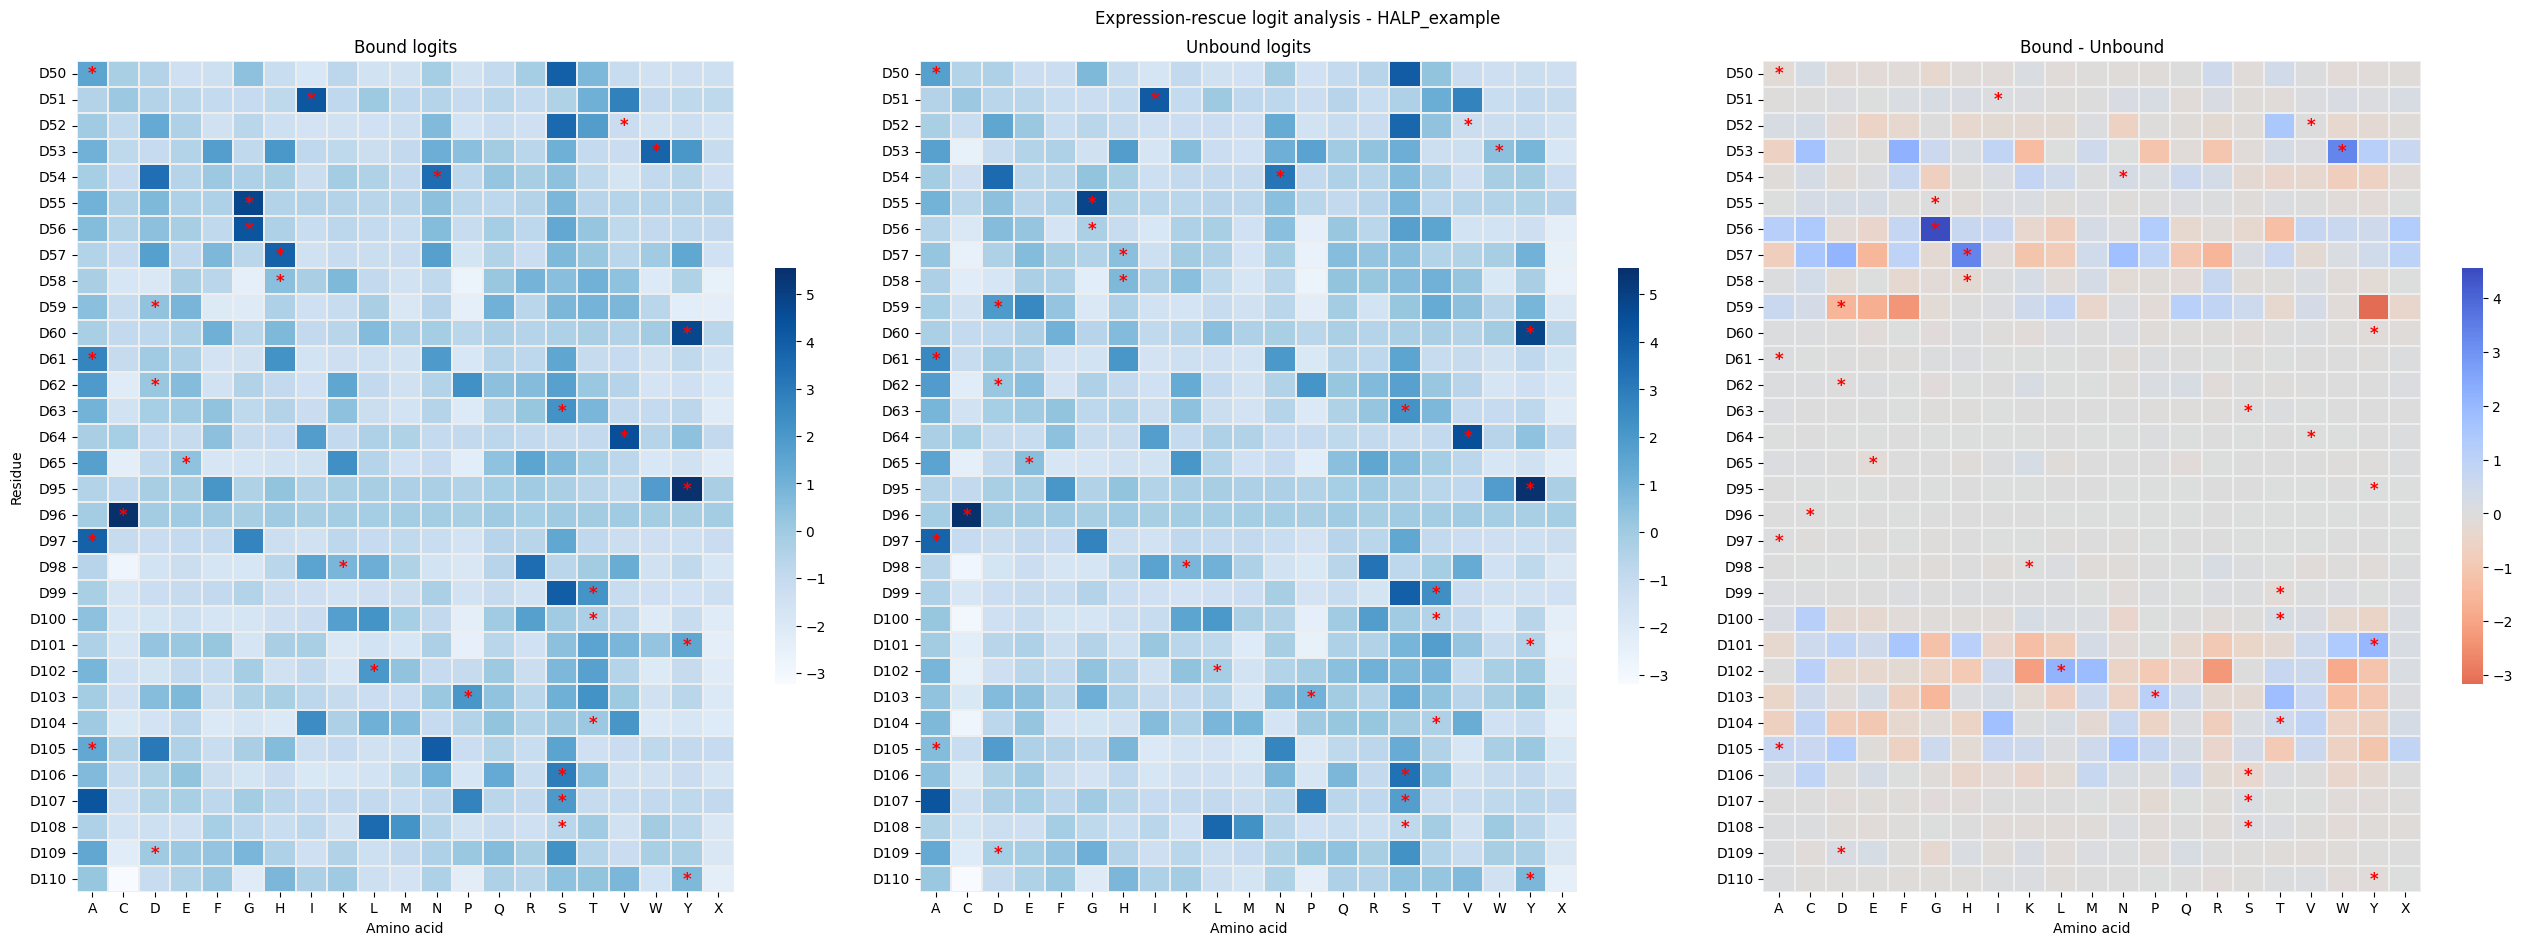

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(3 * 0.35 * n_aa + 4, max(6, 0.3 * n_res)))

# Color convention (consistent with the Step 8 3-D views): low = red, high = blue.
panels = [
    ("Bound logits", bound_mat, "Blues", None),
    ("Unbound logits", unbound_mat, "Blues", None),
    ("Bound - Unbound", diff_mat, "coolwarm_r", 0.0),
]

for ax, (title, mat, cmap, center) in zip(axes, panels):
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=alphabet,
        yticklabels=ordered_residues,
        cbar_kws={"shrink": 0.5},
        linewidths=0.2,
        linecolor="#eeeeee",
    )
    ax.set_title(title)
    ax.set_xlabel("Amino acid")
    ax.set_ylabel("Residue" if title == "Bound logits" else "")
    for i, wt in enumerate(wt_aas):
        j = aa_to_col[wt]
        ax.text(
            j + 0.5, i + 0.5, "*",
            ha="center", va="center",
            color="red", fontsize=12, fontweight="bold",
        )

fig.suptitle(f"Expression-rescue logit analysis - {stem}", fontsize=12)
fig.tight_layout()

heatmap_path = output_dir / "heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print(f"Wrote {heatmap_path}")
plt.show()

## Step 8 - Logit-colored PDBs + inline viewer

Write two copies of the structure with the B-factor column replaced by the WT amino acid logit:

- `<stem>_logits.pdb` - bound complex, colored by **bound-state** logits
- `<stem>_unbound_logits.pdb` - antigen-removed copy, colored by **unbound-state** logits

Both are rendered inline with `py3Dmol` using a **red-white-blue** gradient. **Red = low logit** (WT is disfavored at that position — bad for folding/binding in that state); **blue = high logit** (WT is preferred). Residues outside the rescue set are shown in light gray for context.

The same files open in PyMOL with `spectrum b, red_white_blue` for a higher-fidelity view.

In [11]:
import matplotlib
import matplotlib.colors as mcolors

def write_logit_pdb(src_pdb, dst_pdb, logits_dict, wt_map):
    """Copy src_pdb to dst_pdb with B-factor replaced by each residue's WT logit."""
    wt_logit_by_res = {
        res_name: float(aa_dict.get(wt_map.get(res_name), 0.0))
        for res_name, aa_dict in logits_dict.items()
        if wt_map.get(res_name) is not None
    }
    with open(src_pdb) as f_in, open(dst_pdb, "w") as f_out:
        for line in f_in:
            if line.startswith(("ATOM", "HETATM")):
                chain = line[21]
                resnum = line[22:26].strip()
                res_key = f"{chain}{resnum}"
                score = wt_logit_by_res.get(res_key, 0.0)
                # B-factor column is columns 61-66 (0-indexed 60:66), 6.2f.
                line = line[:60] + f"{score:6.2f}" + line[66:]
            f_out.write(line)
    return wt_logit_by_res

bound_logit_pdb = output_dir / f"{stem}_logits.pdb"
unbound_logit_pdb = output_dir / f"{stem}_unbound_logits.pdb"

bound_wt_logits = write_logit_pdb(
    bound_pdb_path, bound_logit_pdb, bound_logits, wt_bound,
)
unbound_wt_logits = write_logit_pdb(
    unbound_pdb_path, unbound_logit_pdb, unbound_logits, wt_unbound,
)


# Color convention: low logit (WT not preferred) = red, high logit (WT preferred) = blue.
def show_logit_structure(pdb_path, wt_logit_by_res, vmin, vmax, title, cmap_name="bwr_r"):
    """Render a PDB inline with py3Dmol, cartoon colored per-residue by logit."""
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps[cmap_name]

    with open(pdb_path) as f:
        pdb_text = f.read()
    view = py3Dmol.view(width=500, height=400)
    view.addModel(pdb_text, "pdb")
    view.setStyle({}, {"cartoon": {"color": "lightgray"}})
    for res_name, score in wt_logit_by_res.items():
        m = re.match(r"([A-Za-z]+)(\d+)", res_name)
        if not m:
            continue
        chain, resnum = m.group(1), m.group(2)
        hex_color = mcolors.to_hex(cmap(norm(score)))
        view.setStyle(
            {"chain": chain, "resi": resnum},
            {"cartoon": {"color": hex_color}},
        )
    view.zoomTo()
    display(Markdown(f"**{title}**"))
    display({"text/html": view._repr_html_()}, raw=True)

# Shared color scale across the two views so the panels are directly comparable.
all_scores = list(bound_wt_logits.values()) + list(unbound_wt_logits.values())
vmin, vmax = float(min(all_scores)), float(max(all_scores))

display(Markdown(
    f"Wrote `{bound_logit_pdb.name}` and `{unbound_logit_pdb.name}` to `{output_dir}`.\n\n"
    f"Shared color scale: **{vmin:+.2f}** (red, WT disfavored) → "
    f"**{vmax:+.2f}** (blue, WT favored)."
))

show_logit_structure(bound_logit_pdb, bound_wt_logits, vmin, vmax, "Bound")
show_logit_structure(unbound_logit_pdb, unbound_wt_logits, vmin, vmax, "Unbound")

display(Markdown(
    "**Higher-fidelity view in PyMOL:**\n"
    f"```\n"
    f"pymol {bound_logit_pdb} -d 'spectrum b, red_white_blue'\n"
    f"pymol {unbound_logit_pdb} -d 'spectrum b, red_white_blue'\n"
    f"```"
))

Wrote `HALP_example_logits.pdb` and `HALP_example_unbound_logits.pdb` to `/home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output`.

Shared color scale: **-1.46** (red, WT disfavored) → **+6.10** (blue, WT favored).

**Bound**

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Unbound**

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Higher-fidelity view in PyMOL:**
```
pymol /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/HALP_example_logits.pdb -d 'spectrum b, red_white_blue'
pymol /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/HALP_example_unbound_logits.pdb -d 'spectrum b, red_white_blue'
```

## Interpretation

> **The final output is the green "Final rescue mutations" box at the top of Step 6's output** (e.g. `V52S · S108L · T100L`). Introduce those substitutions into the antibody sequence, re-express, and measure expression/binding. Everything else — the ranking table, heatmap, 3-D views, per-residue CSVs — is **additional information** that helps you understand how those mutations were selected. Most users can ignore it unless something in the final list looks suspicious.

> **Output quality depends on input structure quality.** This pipeline reads per-residue structural context (backbone geometry + local environment) to produce the logits that drive every downstream decision. If the input complex has low resolution, misfolded regions, poor quality, etc., the resulting rescue mutations may be unreliable. If the final mutation list looks odd — e.g. the selected positions are far from the interface, or key-binding flags are missing in obvious hotspots — suspect input quality first before re-tuning thresholds.

If you want to understand why those mutations were picked:

- **`key_binding_residues.csv`** — which positions were flagged (Δ-based + user-specified + final set)
- **`rescue_ranking.csv`** — full ordered list; `top_k=True` rows are the ones the green box shows
- **`heatmap.png`** — per-residue 21-AA logit grids for bound / unbound / difference
- **`<stem>_logits.pdb`** / **`<stem>_unbound_logits.pdb`** — logit painted onto the structure as B-factor (open in PyMOL with `spectrum b, red_white_blue`)
- **Step 8 inline 3-D views** — same as above, in-notebook (GitHub won't render the interactive widget; see notebook-top banner)

Color convention throughout: **red = low logit (WT disfavored) · blue = high logit (WT preferred)**.

Citations: Dauparas et al. 2022 (ProteinMPNN), 2025 (LigandMPNN).